In [5]:
!pip install numpy==1.26.4 --force-reinstall --quiet


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.15.3 which is incompatible.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.40.3 which is incompatible.
google-colab 1.0.0 requires notebook==6.5.7, but you have notebook 6.5.4 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.3, but you have requests 2.32

In [6]:
import numpy as np
print("✅ NumPy version:", np.__version__)


✅ NumPy version: 1.26.4


In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/obb-dataset-co2/custom_merged_obb/data.yaml
/kaggle/input/obb-dataset-co2/custom_merged_obb/labels/train.cache
/kaggle/input/obb-dataset-co2/custom_merged_obb/labels/valid.cache
/kaggle/input/obb-dataset-co2/custom_merged_obb/labels/valid/Door2765_png.rf.841d21462ed873632a60ecf0695f7201.txt
/kaggle/input/obb-dataset-co2/custom_merged_obb/labels/valid/2611_jpg.rf.a080f9fc31f30e8e82d6a1f263a6fa1f.txt
/kaggle/input/obb-dataset-co2/custom_merged_obb/labels/valid/06030-928120060232-2-LGA_jpg.rf.8fdca063142a02b3db12ccefcfc85d93.txt
/kaggle/input/obb-dataset-co2/custom_merged_obb/labels/valid/01163_jpg.rf.ccc20a810964b74d2d7b9e084aebc101.txt
/kaggle/input/obb-dataset-co2/custom_merged_obb/labels/valid/Door0091_png.rf.2248152cc975ca056be17735ac52e846.txt
/kaggle/input/obb-dataset-co2/custom_merged_obb/labels/valid/2490_jpg.rf.fe5837d247f64e14679ada87bf412afd.txt
/kaggle/input/obb-dataset-co2/custom_merged_obb/labels/valid/Door0679_png.rf.d6fcc3947bf0fabf66583e2c3e7fe37d.txt
/kagg

In [9]:
!pip install ultralytics==8.3.209

from ultralytics import YOLO
import torch, shutil

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla P100-PCIE-16GB


In [12]:
zip_path = "/kaggle/input/obb-dataset-co2/custom_merged_obb.zip"
extract_path = "/kaggle/input/obb-dataset-co2/custom_merged_obb"

if os.path.exists(zip_path):
    print("Extracting dataset...")
    shutil.unpack_archive(zip_path, extract_path)
else:
    print("Dataset already extracted.")

print("Dataset path:", extract_path)

Dataset already extracted.
Dataset path: /kaggle/input/obb-dataset-co2/custom_merged_obb


In [13]:


yaml_path = "/kaggle/input/obb-dataset-co2/custom_merged_obb/data.yaml"

# Just print and visually confirm
!cat {yaml_path}

# Optionally check that the train/valid folders exist
print("\nChecking folders:")
!ls /kaggle/input/obb-dataset-co2/custom_merged_obb/images
!ls /kaggle/input/obb-dataset-co2/custom_merged_obb/images/valid | head -n 5


# train: E:/sem7/FYP/9_24/objectdetetction/datasets/custom_merged_obb/images/train
# val: E:/sem7/FYP/9_24/objectdetetction/datasets/custom_merged_obb/images/valid

# names:
#   0: fire_extinguisher
#   1: switch_panel
#   2: door
#   3: gauge
#   4: person


# data.yaml for OBB YOLO11 (Kaggle version)

path: /kaggle/input/obb-dataset-co2/custom_merged_obb  # root dataset folder (update to your uploaded dataset name)
train: images/train
val: images/valid

# number of classes
nc: 4        # example – change to your actual number of classes

# class names
names:
  0: fire_extinguisher
  1: switch_panel
  2: door
  3: gague


Checking folders:
train  valid
00002_jpg.rf.269e7687a70b74aab01c2865037fb870.jpg
00011-418319060016-1-FINAL2_jpg.rf.62f28fbb3aa0423840d89370d8b302c7.jpg
00011-418319060016-1-FINAL3_jpg.rf.89f3db1594957449bcd70c255d53332b.jpg
00017_jpg.rf.a8d2aefe6e0729ff80e5f3fc50c52a17.jpg
00020-418319100144-1-FINAL2_jpg.rf.e517edace41907ec6c766dcb19205689.jpg
ls: write error: Broke

In [14]:
!pip install ultralytics==8.3.209 opencv-python matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 106.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 85.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [15]:
from ultralytics import YOLO
print("✅ Ultralytics version check passed")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics version check passed


In [17]:
from ultralytics.data.utils import check_det_dataset

print("Checking dataset integrity...")
dataset_info = check_det_dataset(yaml_path)
print("Dataset verified successfully!")
print(f"Train: {dataset_info['train']}")
print(f"Val:   {dataset_info.get('val', 'N/A')}")
print(f"Classes: {dataset_info['names']}")

Checking dataset integrity...
Dataset verified successfully!
Train: /kaggle/input/obb-dataset-co2/custom_merged_obb/images/train
Val:   /kaggle/input/obb-dataset-co2/custom_merged_obb/images/valid
Classes: {0: 'fire_extinguisher', 1: 'switch_panel', 2: 'door', 3: 'gague'}


In [14]:
import os

base = "/kaggle/input/obb-dataset-co2/custom_merged_obb"
for sub in ["images/train", "images/valid", "labels/train", "labels/valid"]:
    path = os.path.join(base, sub)
    print(f"\n🔍 Checking {path}")
    print("Count:", len(os.listdir(path)))
    bad = [f for f in os.listdir(path) if os.path.getsize(os.path.join(path, f)) == 0]
    if bad:
        print("Empty files:", bad[:5])
    else:
        print("No empty files found")



🔍 Checking /kaggle/input/obb-dataset-co2/custom_merged_obb/images/train
Count: 7001
No empty files found

🔍 Checking /kaggle/input/obb-dataset-co2/custom_merged_obb/images/valid
Count: 1751
No empty files found

🔍 Checking /kaggle/input/obb-dataset-co2/custom_merged_obb/labels/train
Count: 7001
Empty files: ['image-14_jpg.rf.bb0a30b951b4a2e0ecb1bb32d27eb75d.txt', 'image_72_jpg.rf.7a5729f9a6123032ee2ac0a7a590091a.txt', 'frame_384_jpg.rf.8a05d86b7c141ffe0f3ffe6e2fda174d.txt', 'image-18_jpg.rf.a58cc18fa5f73e5e132c269a37f4de4a.txt', 'image_43_jpg.rf.8e92d072df380b9aab4f87d05c47cb79.txt']

🔍 Checking /kaggle/input/obb-dataset-co2/custom_merged_obb/labels/valid
Count: 1751
Empty files: ['image_19_jpg.rf.c27d3b33a7cada830c4aabe49151bf57.txt', 'image_27_jpg.rf.d568009a70a684228293b93071af0b44.txt', 'image_46_jpg.rf.f48cfd2f5ffb137e56956a777fe8f0a2.txt']


In [18]:
import shutil, os

src = "/kaggle/input/obb-dataset-co2/custom_merged_obb"
dst = "/kaggle/working/custom_merged_obb"

# copy entire dataset tree (takes ~1-2 min)
if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print("Dataset copied to /kaggle/working/")
else:
    print("Dataset already exists in /kaggle/working/")


Dataset copied to /kaggle/working/


In [20]:
# clean the copy in /kaggle/working/
def remove_empty_labels(base_path):
    count_removed = 0
    for sub in ["labels/train", "labels/valid"]:
        folder = os.path.join(base_path, sub)
        for f in os.listdir(folder):
            path = os.path.join(folder, f)
            if os.path.getsize(path) == 0:
                os.remove(path)
                img_name = f.replace(".txt", ".jpg")
                for img_dir in ["images/train", "images/valid"]:
                    img_path = os.path.join(base_path, img_dir, img_name)
                    if os.path.exists(img_path):
                        os.remove(img_path)
                count_removed += 1
    print(f"Removed {count_removed} empty label files and their images.")

remove_empty_labels("/kaggle/working/custom_merged_obb")


Removed 0 empty label files and their images.


In [21]:

import sys, types, os

# Disable external loggers
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_DISABLED"] = "true"
os.environ["RAY_AIR_NEW_OUTPUT"] = "0"

# Create dummy ray modules so any 'import ray.train._internal.session' resolves safely
ray = types.ModuleType("ray")
train = types.ModuleType("train")
_internal = types.ModuleType("_internal")
session = types.ModuleType("session")
session._get_session = lambda: None   # <- the problematic call returns None harmlessly
_internal.session = session
train._internal = _internal
ray.train = train
sys.modules["ray"] = ray
sys.modules["ray.train"] = train
sys.modules["ray.train._internal"] = _internal
sys.modules["ray.train._internal.session"] = session

print("Ray hard-blocked & W&B disabled")


Ray hard-blocked & W&B disabled


In [22]:
yaml_path = "/kaggle/working/custom_merged_obb/data.yaml"
with open(yaml_path, "r") as f:
    txt = f.read()
txt = txt.replace("/kaggle/input/obb-dataset-co2/custom_merged_obb", "/kaggle/working/custom_merged_obb")
with open(yaml_path, "w") as f:
    f.write(txt)
print("data.yaml now points to /kaggle/working/custom_merged_obb")


data.yaml now points to /kaggle/working/custom_merged_obb


In [23]:
import ultralytics
print(ultralytics.__version__)


8.3.209


In [24]:
from ultralytics import YOLO

model = YOLO("yolo11s-obb.pt")
results = model.train(
    data="/kaggle/working/custom_merged_obb/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=0,
    cache=False,
    project="obb_run",
    name="train_final_fixed",
    save_period=5,
    patience=20,
    lr0=0.01,
    augment=True
)


Ultralytics 8.3.209 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/custom_merged_obb/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-obb.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train_final_fixed, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=2

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       1747       3369      0.923      0.911      0.937      0.855
     fire_extinguisher        664       1309       0.95      0.907      0.957      0.867
          switch_panel        240       1215      0.753      0.745      0.804      0.627
                  door        524        526      0.994      0.997      0.995       0.97
                 gague        319        319      0.995      0.997      0.994      0.955
Speed: 0.1ms preprocess, 4.2ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to /kaggle/working/obb_run/train_final_fixed


In [25]:
import os
os.listdir("/kaggle/working/obb_run/train_final_fixed/weights")


['epoch5.pt',
 'epoch30.pt',
 'epoch0.pt',
 'best.pt',
 'epoch40.pt',
 'epoch35.pt',
 'epoch45.pt',
 'epoch20.pt',
 'last.pt',
 'epoch25.pt',
 'epoch10.pt',
 'epoch15.pt']

In [26]:
import os, shutil

final_path = "/kaggle/working/final_weights"
os.makedirs(final_path, exist_ok=True)

src_folder = "/kaggle/working/obb_run/train_final_fixed/weights"

for w in ["best.pt", "last.pt"]:
    src = os.path.join(src_folder, w)
    if os.path.exists(src):
        shutil.copy(src, final_path)
        print(f"Copied {w} → {final_path}")

print("Check /kaggle/working/final_weights for saved models.")


Copied best.pt → /kaggle/working/final_weights
Copied last.pt → /kaggle/working/final_weights
Check /kaggle/working/final_weights for saved models.


In [36]:
import shutil

# Path to your training results
src_folder = "/kaggle/working/obb_run"
zip_path = "/kaggle/working/train_final_fixed_all.zip"

# Create ZIP archive
shutil.make_archive(zip_path.replace(".zip", ""), "zip", src_folder)
print("Folder zipped successfully:", zip_path)


Folder zipped successfully: /kaggle/working/train_final_fixed_all.zip


Ultralytics 8.3.209 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s-obb summary (fused): 109 layers, 9,700,335 parameters, 0 gradients, 22.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 785.9±180.8 MB/s, size: 24.3 KB)
val: Scanning /kaggle/working/custom_merged_obb/labels/valid.cache... 1748 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1748/1748 3.8Mit/s 0.0s0s
val: /kaggle/working/custom_merged_obb/images/valid/capture_004_png.rf.26efada07efcb1709f2f1b1f033f14ca.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0172]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 5.4it/s 20.3s0.2s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       1747       3369      0.923      0.911      0.938      0.855
     fire_extinguisher        664       1309       0.95      0.907      0.957      0.867
          switch_panel        240       1215      0.752      0.745      0.804      0.628
                  door        524        526      0.994      0.997      0.995       0.97
                 gague        319        319      0.995      0.997      0.994      0.954
Speed: 0.3ms preprocess, 4.9ms inference, 0.0ms loss, 2.4ms postprocess per image
Results saved to /kaggle/working/runs/obb/val
Validation complete — results saved to: /kaggle/working/runs/obb/val
results.csv not found; skipping curve plots
🖼️ BoxF1_curve.png


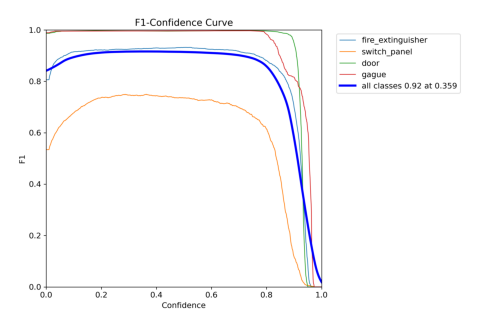

🖼️ BoxR_curve.png


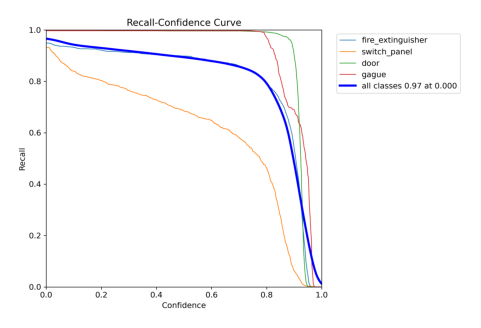

🖼️ BoxP_curve.png


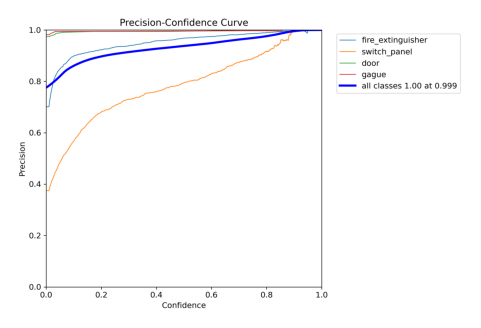

🖼️ confusion_matrix.png


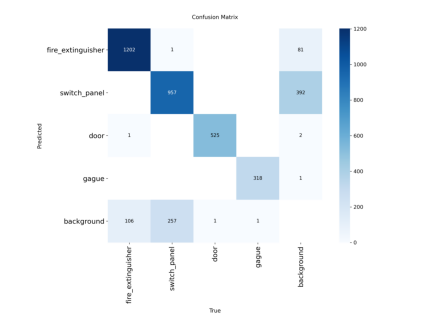

🖼️ BoxPR_curve.png


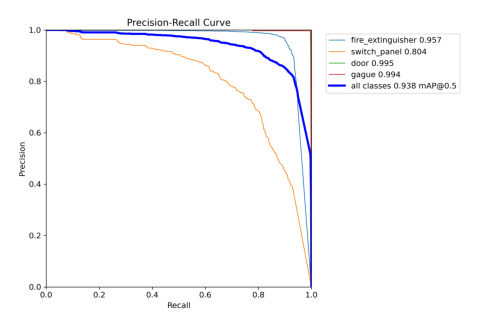

🖼️ confusion_matrix_normalized.png


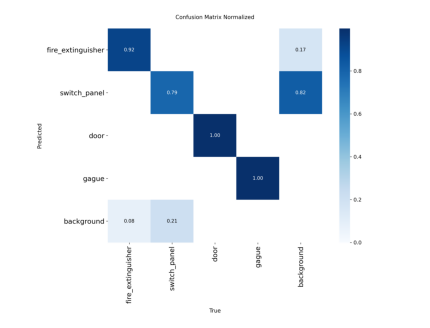

In [30]:
# =============================================
# Auto-generate YOLO validation plots (mAP, PR, F1, Confusion Matrix)
# =============================================
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import glob
import cv2
import os

# Path to best weights and dataset yaml
best_model = "/kaggle/working/obb_run/train_final_fixed/weights/best.pt"
data_yaml = "/kaggle/working/custom_merged_obb/data.yaml"

# Validate and generate all plots
model = YOLO(best_model)
metrics = model.val(data=data_yaml, save=True)
print(f"Validation complete — results saved to: {metrics.save_dir}")

# Plot losses and mAP curves from CSV
csv_path = os.path.join(metrics.save_dir, "results.csv")
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)

    plt.figure()
    plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
    plt.plot(df["epoch"], df["train/cls_loss"], label="Cls Loss")
    plt.plot(df["epoch"], df["train/dfl_loss"], label="DFL Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training Loss Curves")
    plt.legend(); plt.grid(True); plt.show()

    plt.figure()
    plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
    plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
    plt.xlabel("Epoch"); plt.ylabel("mAP"); plt.title("Validation mAP Progress")
    plt.legend(); plt.grid(True); plt.show()
else:
    print("results.csv not found; skipping curve plots")

# Display all YOLO-generated images (curves, confusion matrices)
for img_path in glob.glob(os.path.join(metrics.save_dir, "*.png")):
    print("🖼️", os.path.basename(img_path))
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


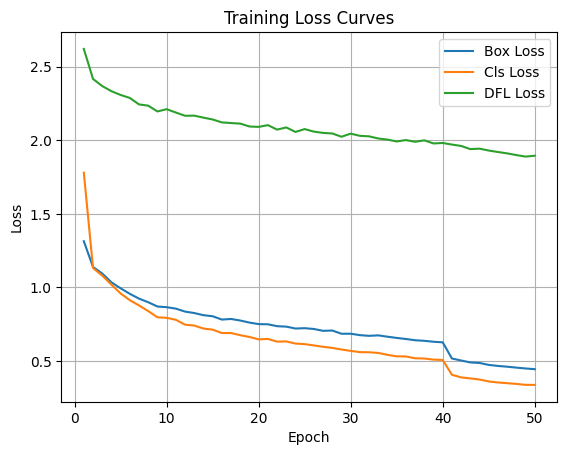

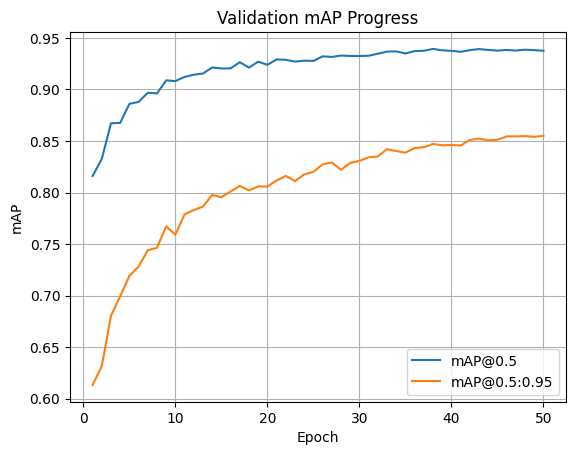

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training log
df = pd.read_csv("/kaggle/working/obb_run/train_final_fixed/results.csv")

# Plot loss curves
plt.figure()
plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Cls Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="DFL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

# Plot mAP curves
plt.figure()
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation mAP Progress")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
from ultralytics import YOLO

# Load the best model
model = YOLO("/kaggle/working/obb_run/train_final_fixed/weights/best.pt")

# Run validation on the same validation split defined in your data.yaml
metrics = model.val(data="/kaggle/working/custom_merged_obb/data.yaml")

# Print summary
print(metrics)


Ultralytics 8.3.209 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11s-obb summary (fused): 109 layers, 9,700,335 parameters, 0 gradients, 22.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1116.5±426.9 MB/s, size: 43.3 KB)
val: Scanning /kaggle/working/custom_merged_obb/labels/valid.cache... 1748 images, 0 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1748/1748 2.8Mit/s 0.0s0s
val: /kaggle/working/custom_merged_obb/images/valid/capture_004_png.rf.26efada07efcb1709f2f1b1f033f14ca.jpg: ignoring corrupt image/label: non-normalized or out of bounds coordinates [     1.0172]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 110/110 5.6it/s 19.7s0.2s


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all       1747       3369      0.923      0.911      0.938      0.855
     fire_extinguisher        664       1309       0.95      0.907      0.957      0.867
          switch_panel        240       1215      0.752      0.745      0.804      0.628
                  door        524        526      0.994      0.997      0.995       0.97
                 gague        319        319      0.995      0.997      0.994      0.954
Speed: 0.2ms preprocess, 4.2ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to /kaggle/working/runs/obb/val2
ultralytics.utils.metrics.OBBMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e2041edccd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    

In [35]:
# Visualize a few validation images with predicted rotated boxes
model.predict(
    source="/kaggle/working/custom_merged_obb/images/valid",
    conf=0.5,
    save=True,
    project="obb_run",
    name="val_predictions"
)



WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1748 /kaggle/working/custom_merged_obb/images/valid/00002_jpg.rf.269e7687a70b74aab01c2865037fb870.jpg: 640x384 1 fire_extinguisher, 56.1ms
image 2/1748 /kaggle/working/custom_merged_obb/images/valid/00011-418319060016-1-FINAL2_jpg.rf.62f28fbb3aa0423840d89370d8b302c7.jpg: 640x640 4 switch_panels, 10.5ms
image 3/1748 /kaggle/working/custom_merged_obb/images/valid/00011-418319060016-1-FINAL3_jpg.rf.89f3db1594957449bcd70c255d53332b.jpg: 640x640 2 s

[ultralytics.engine.results.Results object with attributes:
 
 boxes: None
 keypoints: None
 masks: None
 names: {0: 'fire_extinguisher', 1: 'switch_panel', 2: 'door', 3: 'gague'}
 obb: ultralytics.engine.results.OBB object
 orig_img: array([[[ 52,  73, 125],
         [ 52,  73, 125],
         [ 52,  73, 125],
         ...,
         [ 77, 101, 155],
         [ 76, 100, 154],
         [ 75,  99, 153]],
 
        [[ 52,  73, 125],
         [ 52,  73, 125],
         [ 52,  73, 125],
         ...,
         [ 75,  99, 153],
         [ 75,  99, 151],
         [ 76,  97, 152]],
 
        [[ 52,  73, 124],
         [ 52,  73, 124],
         [ 53,  74, 125],
         ...,
         [ 75,  97, 149],
         [ 75,  98, 148],
         [ 76,  97, 149]],
 
        ...,
 
        [[120, 146, 182],
         [122, 148, 184],
         [127, 151, 187],
         ...,
         [114, 155, 200],
         [111, 152, 197],
         [111, 150, 195]],
 
        [[123, 149, 185],
         [124, 150, 186],
       

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = r"E:\path\to\obb_run\train_final_fixed4\results.csv"
df = pd.read_csv(csv_path)

plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation mAP Progress")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(df["epoch"], df["train/box_loss"], label="Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Cls Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="DFL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()
